# USING VECTORS AS A MEANS OF FINDING SIMILAR OBJECTS

The term vector refers to a quantity that has both magnitude and direction, where magnitude refers to the amount of something. They’re used extensively in physics to describe the direction and strength of a force or the motion of an object. For example, you may have heard the phrase “velocity vector,” which describes the amount of speed an object has and the direction in which it's travelling ("heading north east at 30 kph”) or a machine in a factory might be specified to “apply a force of 10 newtons vertically down” - the magnitude of the force is 10 newtons and the direction is downwards.

Vectors are widely used in machine learning due to a very simple caclulation called the **vector dot product** that provides a quick way to calculate how similar two vectors are to each other based upon their length and direction. Vectors with similar lengths and directions will be more alike than vectors pointing in different directions or with different lengths.

In Machine Learning, if we can represent objects as vectors, we can compare them using the dot product and find which are similar to each other and which are not. For example, in Language Models if we can find a way to represent words and phrases as vectors, the dot product allows us to find similar words; it is this that forms the basis of word prediction.

**Dot Product Calculation**</p>
If I have two vectors $p$ and $q$, each with two features $(a1, b1)$ and $(a2, b2)$

i.e. $\mathbf{p} = \begin{pmatrix} a_1 \\ b_1 \end{pmatrix}$ and $\mathbf{q} = \begin{pmatrix} a_2 \\ b_2 \end{pmatrix}$

**Dot product (geometric form)**</p>
- $\mathbf{p} \cdot \mathbf{q} = \|\mathbf{p}\| \|\mathbf{q}\| \cos(\theta)$

where:</p>
- $\|\mathbf{p}\| = \sqrt{a_1^2 + b_1^2}$
- $\|\mathbf{q}\| = \sqrt{a_2^2 + b_2^2}$
- $\theta$ is the angle between the vectors.

**Dot product (algebraic form):**</p>
- $\mathbf{p} \cdot \mathbf{q} = a_1 a_2 + b_1 b_2$




Let's start with 4 vectors each with 2 features (2 dimensions). We'll plot them on a graph with different colours.

- v1, v2 : pointing in ery similar directions and of similar length
- v3     : pointing in a similar direction to v1 and v2 but of shorter length
- v4     : pointing in the opposite direction to v1 but of a similar length

We would expect that the dot product of v1 and v2 would be the highest


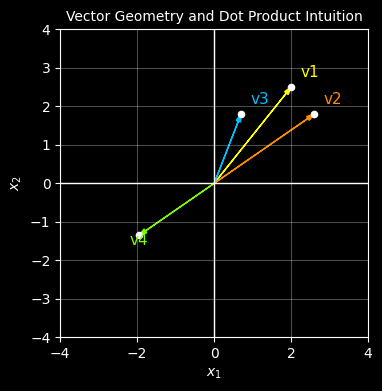

In [ ]:
# import the libraries we need
import numpy as np
import numpy.random
import matplotlib.pyplot as plt
%matplotlib inline

# ------------------------------------------------------------
# Define four vectors
# ------------------------------------------------------------
v1 = np.array([2.0, 2.5])
v2 = np.array([2.6, 1.8])
v3 = np.array([0.7, 1.8])
v4 = -0.75*(v2) # make this one 3/4 the lenght of v2 but in the opposite directio

# put them in a list so we can graph them easily and create a corresponding list of labels and colours
vectors = [v1, v2, v3, v4]
labels = ["v1", "v2", "v3", "v4"]
colors = ["yellow", "darkorange", "deepskyblue", "lawngreen"]

# ------------------------------------------------------------
# Plot them
# ------------------------------------------------------------
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(4, 4))

    for v, label, col in zip(vectors, labels, colors):
        # plot the points
        ax.scatter(v[0], v[1], s=20, color="white", zorder=3)
        
        # plot an arrow to each point
        ax.arrow(
            0, 0, v[0], v[1],
            length_includes_head=True,
            head_width=0.12,
            head_length=0.2,
            linewidth=1,
            color=col
        )

        # label each vector (needs to be offset)
        offset = 0.25
        ax.text(
            v[0] + np.sign(v[0]) * offset,
            v[1] + np.sign(v[1]) * offset,
            label,
            color=col,
            fontsize=11
        )

    ax.axhline(0, color="white", linewidth=1)
    ax.axvline(0, color="white", linewidth=1)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, alpha=0.3)

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title("Vector Geometry and Dot Product Intuition", fontsize="10")

# show the plot
plt.show()


Now let's find which vectors are most similar to vector 1 using the dot product

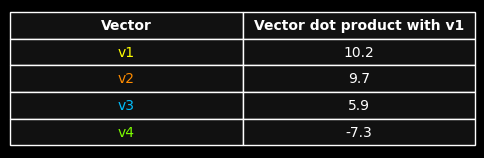

In [4]:
# Compute dot products for each vector againt against vector 1 (v1)
dot_products    = [np.dot(v1, v) for v in vectors]

# create a table for displaying the results
table_data      = [[label, f"{dp:.1f}"] for label, dp in zip(labels, dot_products)]

# plt the table of results
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(6, 1.8))
    ax.axis("off")

    table = ax.table(
        cellText=table_data,
        colLabels=["Vector","Vector dot product with v1"],
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.6)

    # Style cells
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("white")
        cell.set_linewidth(1.0)
        cell.set_facecolor("#111111")

        # Header row
        if row == 0:
            cell.get_text().set_color("white")
            cell.get_text().set_fontweight("bold")

        # First column: colour matches vector colour
        elif col == 0:
            cell.get_text().set_color(colors[row - 1])

        # Dot product column
        else:
            cell.get_text().set_color("white")

# plot the results
plt.show()

**Conclusion**</p>
From the first plot, it's visually clear that vector v2 is most like vector v1 because it has a similar length and direction whereas v4 points in the complete opposite direction.</p>
From the table, calculating the dot product of each vector with v1, we reach the same conclusoin mathematically - the dot product of v2 with v1 is the highest whereas that of v4 and v1 score the lowest (in fact its negative) becuase v4 points in the complete opposite direction to v1.</p>

**Insight**</p>
If we can represent real-world items as vectors, there's a simple mathematical formula to determine similarity. FOr example, by representing words, sounds, images etc. as vectors then the dot product can help find words that alike, find patterns in images to help identify them, match sounds to each other to identify voices etc. etc..